In [17]:
# Notebook to plot the track recontruction for different radii to fild the best one

import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D 
from matplotlib.colors import LogNorm
import matplotlib.colors as mcolors 
# import plotly.express as px
# import plotly.io as pio

import sys
sys.path.append("../scripts")
from TrackReconstruction_functions import *
from reconstruction_functions import *
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

%matplotlib widget


In [4]:
diff = "5percent"
pressure = 1

# Set the detector size depending on the pressure
density = 5.987*pressure
M = 1000/0.9
det_size = 1000*np.cbrt((4 * M) / (np.pi * density))/2.0
print(det_size)


def LoadMeta(name, reco_mode, reco_name):
    meta = pd.read_hdf(f"../data/TrackRecoOptimization/ATPC_{name}_{pressure}bar_{diff}_reco{reco_mode}_{reco_name}.h5", "meta")
    meta["Type"] = name
    meta["reco_mode"] = reco_mode
    meta["reco_name"] = reco_name
    meta = meta[meta.primary == 1]
    return meta

nubb = []
Bi = []
Tl = []
Single=[]

for i in np.arange(1,7,1):
    nubb.append(LoadMeta("0nubb", i, "sphere"))
    Bi.append(LoadMeta("Bi_ion", i, "sphere"))
    Tl.append(LoadMeta("Tl_ion", i, "sphere"))
    Single.append(LoadMeta("single", i, "sphere"))
    nubb.append(LoadMeta("0nubb", i, "ellipse"))
    Bi.append(LoadMeta("Bi_ion", i, "ellipse"))
    Tl.append(LoadMeta("Tl_ion", i, "ellipse"))
    Single.append(LoadMeta("single", i, "ellipse"))

nubb = pd.concat(nubb)
Bi = pd.concat(Bi)
Tl = pd.concat(Tl)
Single = pd.concat(Single)

Bkgs = pd.concat([Bi, Tl, Single])

display(Bkgs)


3091.169274839764


,event_id,trkID,primary,start,end,length,energy,blob1,blob2,blob1R,...,blob2RTD,Tortuosity1,Tortuosity2,Squiglicity1,Squiglicity2,label,contained,Type,reco_mode,reco_name
0,30060000000,0,1,0,15,3128.635,2.076637,0.287990,0.087358,0.342078,...,0.092400,2.370710,1.076644,1.391079e+00,3.114073e-01,Primary,True,Bi_ion,1,sphere
0,30060000001,0,1,0,1,16.318,2.461797,2.301725,0.160072,2.301725,...,0.160072,1.000000,1.000000,5.328078e-14,5.328078e-14,Primary,False,Bi_ion,1,sphere
0,30060000003,0,1,29,130,3427.272,2.135772,0.378775,0.069616,0.401417,...,0.069616,1.611594,1.032528,9.484594e-01,1.856251e-01,Primary,True,Bi_ion,1,sphere
0,30060000005,0,1,1,12,96.000,2.436724,0.827502,0.001736,0.827502,...,0.001736,1.897367,1.897367,1.387286e+00,1.387286e+00,Primary,False,Bi_ion,1,sphere
0,30060000006,0,1,115,142,3737.544,2.429486,0.206684,0.048917,0.357949,...,0.048917,4.517757,1.035887,2.155774e+00,1.516905e-01,Primary,True,Bi_ion,1,sphere
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,1723235,0,1,0,68,3744.401,2.309951,0.728158,0.300131,1.552528,...,0.368535,2.084491,1.079015,1.303461e+00,3.646895e-01,Primary,False,single,6,ellipse
0,1723260,0,1,0,97,3703.832,2.446421,0.560457,0.504617,1.094084,...,0.578759,1.459395,1.066621,6.224728e-01,2.835368e-01,Primary,True,single,6,ellipse
0,1723264,0,1,13,105,4087.512,2.440737,0.702757,0.308674,1.096644,...,0.331062,1.747528,1.038580,1.015949e+00,1.862767e-01,Primary,True,single,6,ellipse
0,1723267,0,1,65,175,3416.217,2.213169,0.699779,0.272811,1.125376,...,0.289916,1.877835,1.037686,1.563919e+00,2.582072e-01,Primary,True,single,6,ellipse


In [14]:
# Make a plot of the ratio of signal efficiency vs background efficiency vs blob energy

def ScanCut(label, reco_name, range_min, range_max):

    Rs_all  = []
    Es_all  = []

    for i in np.arange(1,7,1):
        Rs = []
        Es = []
        print("On ", i)
        for E in np.linspace(range_min, range_max, 20):
            nubb_cut = nubb[ (nubb.reco_mode == i) & (nubb[label] > E) & (nubb.reco_name == reco_name)]
            Bkgs_cut = Bkgs[ (Bkgs.reco_mode == i) & (Bkgs[label] > E) & (Bkgs.reco_name == reco_name)]
            R = len(nubb_cut)/len(Bkgs_cut)
            Rs.append(R)
            Es.append(E)

        Rs_all.append(Rs)
        Es_all.append(Es)
    return Rs_all, Es_all

On  1
On  2
On  3
On  4
On  5
On  6
On  1
On  2
On  3
On  4
On  5
On  6


Text(0, 0.5, 'Sig Eff/ Bkg Eff')

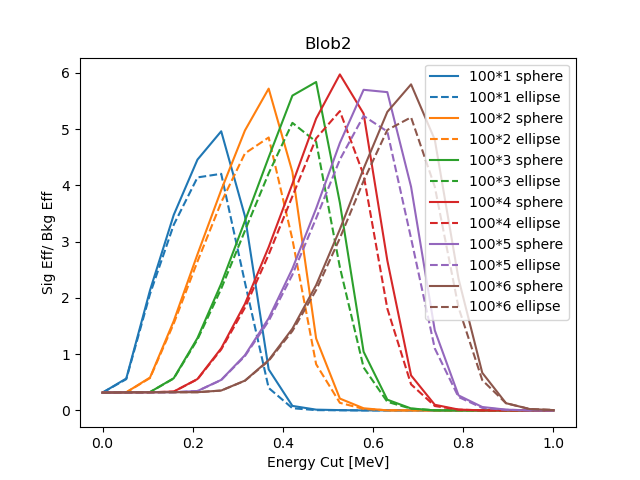

In [18]:
Rs_all_sphere, Es_all_sphere = ScanCut("blob2", "sphere", 0, 1)
Rs_all_ellipse, Es_all_ellipse = ScanCut("blob2", "ellipse", 0, 1)
plt.figure()
for i in np.arange(0,6,1):
    plt.plot(Es_all_sphere[i], Rs_all_sphere[i], label = f"100*{i+1} sphere", linestyle = "-", color = colors[i]);
    plt.plot(Es_all_ellipse[i], Rs_all_ellipse[i], label = f"100*{i+1} ellipse", linestyle = "--", color = colors[i]);
plt.legend()
plt.title("Blob2")
plt.xlabel("Energy Cut [MeV]")
plt.ylabel("Sig Eff/ Bkg Eff")


On  1
On  2
On  3
On  4
On  5
On  6
On  1
On  2
On  3
On  4
On  5
On  6


Text(0, 0.5, 'Sig Eff/ Bkg Eff')

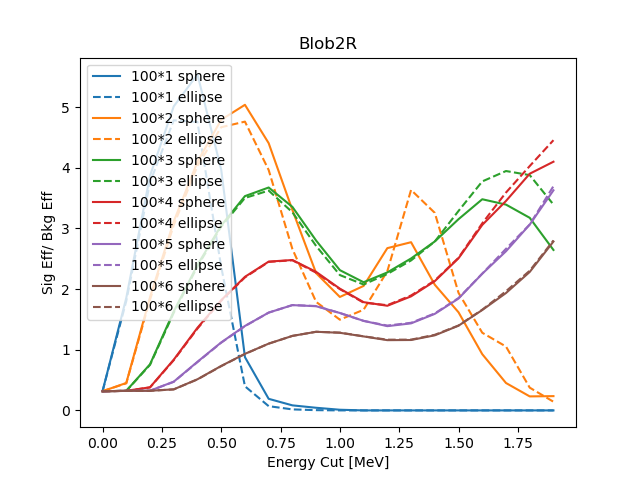

In [19]:
Rs_all_sphere, Es_all_sphere = ScanCut("blob2R", "sphere", 0, 1.9)
Rs_all_ellipse, Es_all_ellipse = ScanCut("blob2R", "ellipse", 0, 1.9)
plt.figure()
for i in np.arange(0,6,1):
    plt.plot(Es_all_sphere[i], Rs_all_sphere[i], label = f"100*{i+1} sphere", linestyle = "-", color = colors[i]);
    plt.plot(Es_all_ellipse[i], Rs_all_ellipse[i], label = f"100*{i+1} ellipse", linestyle = "--", color = colors[i]);
plt.legend()
plt.title("Blob2R")
plt.xlabel("Energy Cut [MeV]")
plt.ylabel("Sig Eff/ Bkg Eff")

Text(0, 0.5, 'Sig Eff/ Bkg Eff')

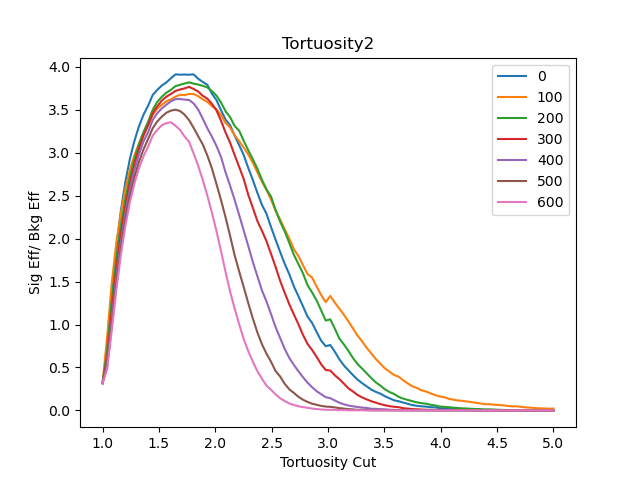

In [19]:
Rs_all, Es_all = ScanCut("Tortuosity2", 1, 5)
plt.figure()
for i in np.arange(0,7,1):
    plt.plot(Es_all[i],Rs_all[i],label = 100*i);
plt.legend()
plt.title("Tortuosity2")
plt.xlabel("Tortuosity Cut")
plt.ylabel("Sig Eff/ Bkg Eff")

Text(0, 0.5, 'Sig Eff/ Bkg Eff')

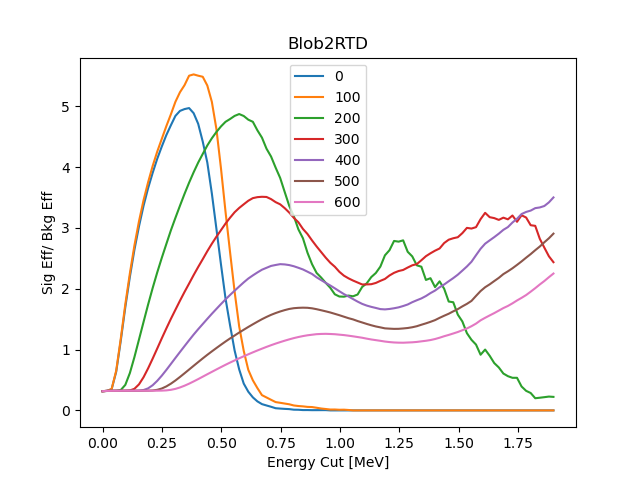

In [20]:
Rs_all, Es_all = ScanCut("blob2RTD", 0, 1.9)
plt.figure()
for i in np.arange(0,7,1):
    plt.plot(Es_all[i],Rs_all[i],label = 100*i);
plt.legend()
plt.title("Blob2RTD")
plt.xlabel("Energy Cut [MeV]")
plt.ylabel("Sig Eff/ Bkg Eff")

Text(0, 0.5, 'Sig Eff/ Bkg Eff')

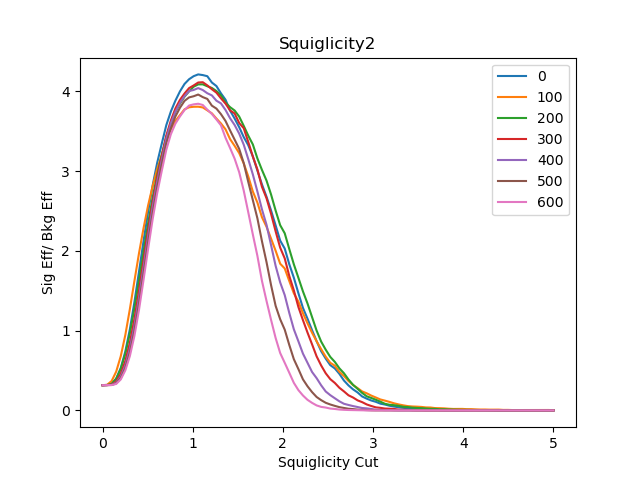

In [21]:
Rs_all, Es_all = ScanCut("Squiglicity2", 0, 5)
plt.figure()
for i in np.arange(0,7,1):
    plt.plot(Es_all[i],Rs_all[i],label = 100*i);
plt.legend()
plt.title("Squiglicity2")
plt.xlabel("Squiglicity Cut")
plt.ylabel("Sig Eff/ Bkg Eff")